In [ ]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# 1. IMPORTS ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import nltk
import time
import warnings
warnings.filterwarnings('ignore')

# NLTK Downloads
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet',
            'averaged_perceptron_tagger', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout,
    Bidirectional, GlobalMaxPooling1D, GlobalAveragePooling1D,
    SpatialDropout1D, BatchNormalization, Input, Concatenate,
    Conv1D, MaxPooling1D, Flatten, LayerNormalization
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint, TensorBoard)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

from wordcloud import WordCloud

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 60)
print("  ALL LIBRARIES IMPORTED SUCCESSFULLY")
print(f"  TensorFlow Version : {tf.__version__}")
print(f"  NumPy Version      : {np.__version__}")
print("=" * 60)

  ALL LIBRARIES IMPORTED SUCCESSFULLY
  TensorFlow Version : 2.20.0
  NumPy Version      : 2.0.2


In [ ]:
# MOUNT DRIVE & LOAD DATASET ───────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/Hotel_Reviews.csv'

df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"  Total Reviews  : {len(df)}")
print(f"  Columns        : {list(df.columns)}")
print(f"\n  Missing Values:\n{df.isnull().sum()}")
print(f"\n  Rating Distribution:\n{df['Rating'].value_counts().sort_index()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  DATASET OVERVIEW
  Total Reviews  : 20491
  Columns        : ['Review', 'Rating']

  Missing Values:
Review    0
Rating    0
dtype: int64

  Rating Distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


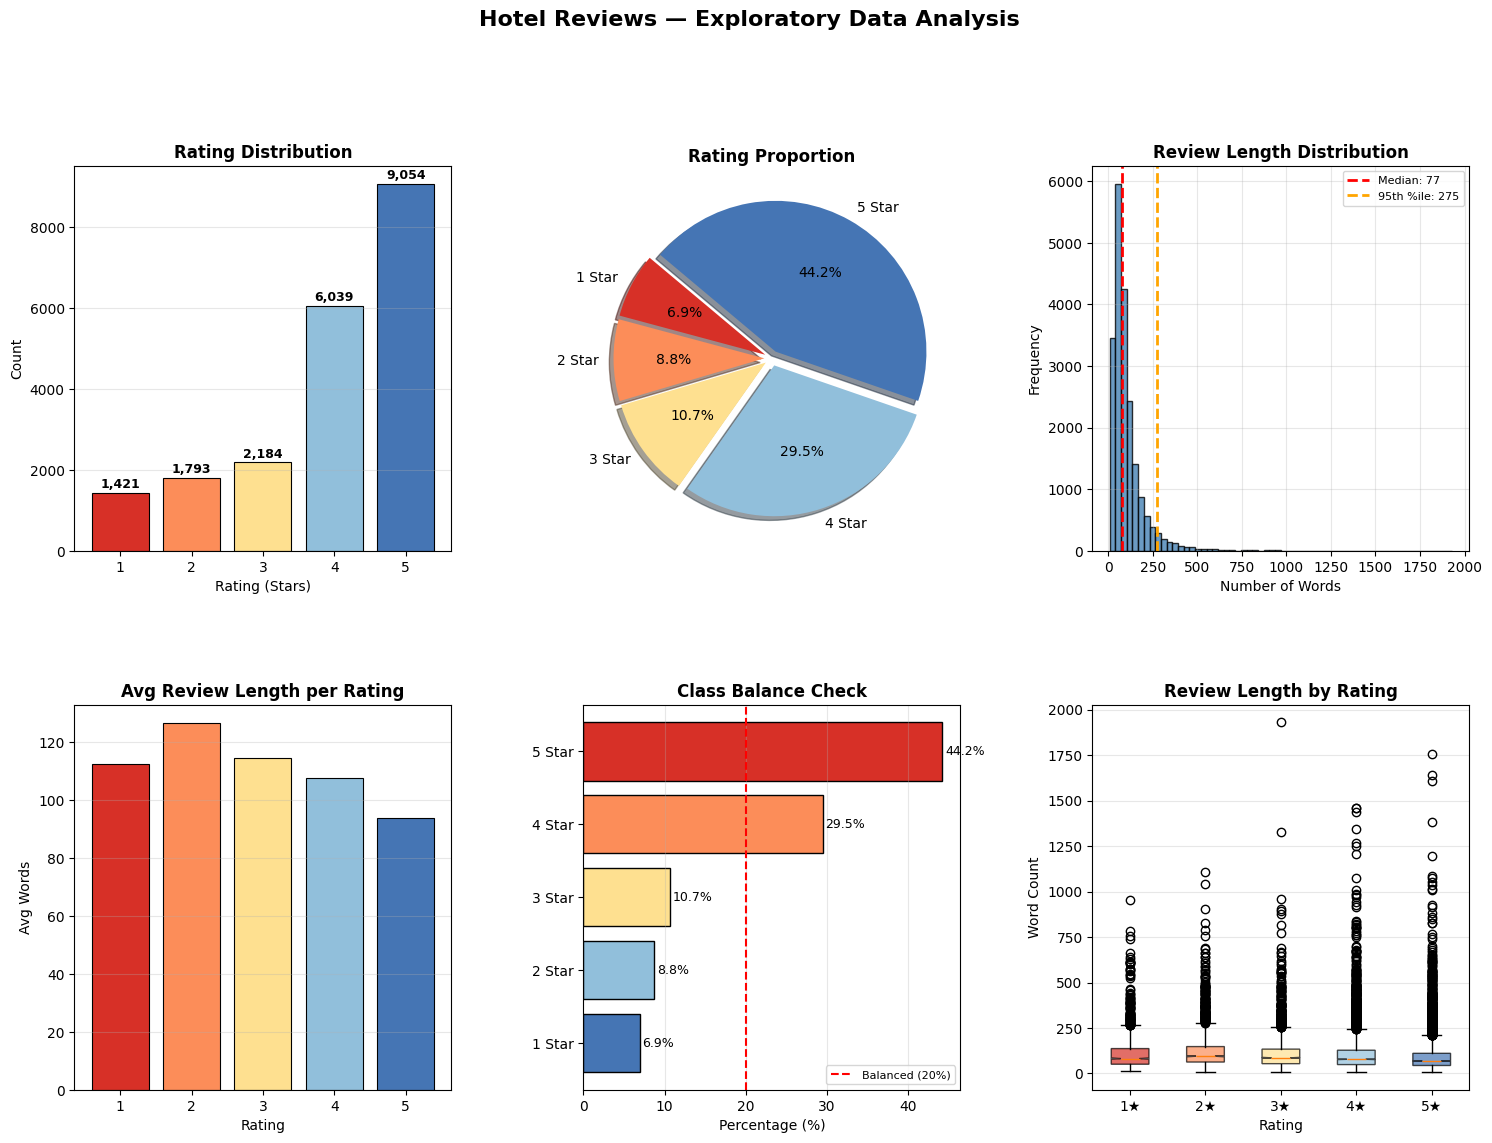


 Review Length Statistics:
count    20491.00
mean       104.38
std        100.66
min          7.00
25%         48.00
50%         77.00
75%        124.00
max       1931.00


In [ ]:
# EXPLORATORY DATA ANALYSIS ────────────────────────────

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Hotel Reviews — Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 3a. Rating Distribution Bar Chart
ax1 = fig.add_subplot(gs[0, 0])
rating_counts = df['Rating'].value_counts().sort_index()
colors_bar = ['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4']
bars = ax1.bar(rating_counts.index, rating_counts.values,
               color=colors_bar, edgecolor='black', linewidth=0.8)
ax1.set_title('Rating Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Rating (Stars)')
ax1.set_ylabel('Count')
for bar, val in zip(bars, rating_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.grid(axis='y', alpha=0.3)

# ── 3b. Rating Distribution Pie Chart
ax2 = fig.add_subplot(gs[0, 1])
explode = (0.05, 0.05, 0.05, 0.05, 0.05)
ax2.pie(rating_counts.values, labels=[f'{i} Star' for i in rating_counts.index],
        autopct='%1.1f%%', colors=colors_bar, explode=explode,
        shadow=True, startangle=140)
ax2.set_title('Rating Proportion', fontsize=12, fontweight='bold')

# ── 3c. Review Length Distribution
ax3 = fig.add_subplot(gs[0, 2])
df['review_length'] = df['Review'].astype(str).apply(lambda x: len(x.split()))
ax3.hist(df['review_length'], bins=60, color='steelblue',
         edgecolor='black', alpha=0.8)
ax3.axvline(df['review_length'].median(), color='red', linestyle='--',
            linewidth=2, label=f"Median: {df['review_length'].median():.0f}")
ax3.axvline(df['review_length'].quantile(0.95), color='orange',
            linestyle='--', linewidth=2,
            label=f"95th %ile: {df['review_length'].quantile(0.95):.0f}")
ax3.set_title('Review Length Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Number of Words')
ax3.set_ylabel('Frequency')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ── 3d. Avg Review Length per Rating
ax4 = fig.add_subplot(gs[1, 0])
avg_len = df.groupby('Rating')['review_length'].mean()
ax4.bar(avg_len.index, avg_len.values, color=colors_bar,
        edgecolor='black', linewidth=0.8)
ax4.set_title('Avg Review Length per Rating', fontsize=12, fontweight='bold')
ax4.set_xlabel('Rating')
ax4.set_ylabel('Avg Words')
ax4.set_xticks([1, 2, 3, 4, 5])
ax4.grid(axis='y', alpha=0.3)

# ── 3e. Class Imbalance Visual
ax5 = fig.add_subplot(gs[1, 1])
total = len(df)
pcts = [(v / total) * 100 for v in rating_counts.values]
ax5.barh([f'{i} Star' for i in rating_counts.index], pcts,
         color=colors_bar[::-1], edgecolor='black')
ax5.axvline(20, color='red', linestyle='--', linewidth=1.5,
            label='Balanced (20%)')
ax5.set_title('Class Balance Check', fontsize=12, fontweight='bold')
ax5.set_xlabel('Percentage (%)')
ax5.legend(fontsize=8)
ax5.grid(axis='x', alpha=0.3)
for i, (pct, val) in enumerate(zip(pcts, rating_counts.values)):
    ax5.text(pct + 0.3, i, f'{pct:.1f}%', va='center', fontsize=9)

# ── 3f. Box Plot: Review Length per Rating
ax6 = fig.add_subplot(gs[1, 2])
data_by_rating = [df[df['Rating'] == r]['review_length'].values
                  for r in sorted(df['Rating'].unique())]
bp = ax6.boxplot(data_by_rating, labels=[f'{i}★' for i in [1,2,3,4,5]],
                 patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax6.set_title('Review Length by Rating', fontsize=12, fontweight='bold')
ax6.set_xlabel('Rating')
ax6.set_ylabel('Word Count')
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_complete.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Review Length Statistics:")
print(df['review_length'].describe().round(2).to_string())

In [ ]:
# TEXT PREPROCESSING PIPELINE ──────────────────────────

STOP_WORDS = set(stopwords.words('english'))
# Keep negation words — critical for sentiment analysis
NEGATION_WORDS = {'not', 'no', 'never', 'neither', 'nor',
                  'cannot', "can't", "won't", "don't", "didn't",
                  "isn't", "wasn't", "weren't", "hasn't", "haven't",
                  "hadn't", "shouldn't", "wouldn't", "couldn't"}
STOP_WORDS -= NEGATION_WORDS  # Remove negations from stopwords

lemmatizer = WordNetLemmatizer()

# Contraction dictionary
CONTRACTIONS = {
    "ain't": "are not", "aren't": "are not", "can't": "cannot",
    "can't've": "cannot have", "could've": "could have",
    "couldn't": "could not", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hasn't": "has not",
    "haven't": "have not", "he'd": "he would", "he'll": "he will",
    "he's": "he is", "i'd": "i would", "i'll": "i will", "i'm": "i am",
    "i've": "i have", "isn't": "is not", "it's": "it is",
    "let's": "let us", "mustn't": "must not", "shan't": "shall not",
    "she'd": "she would", "she'll": "she will", "she's": "she is",
    "shouldn't": "should not", "that's": "that is", "there's": "there is",
    "they'd": "they would", "they'll": "they will", "they're": "they are",
    "they've": "they have", "wasn't": "was not", "we'd": "we would",
    "we're": "we are", "we've": "we have", "weren't": "were not",
    "what'll": "what will", "what're": "what are", "what's": "what is",
    "what've": "what have", "where's": "where is", "who'll": "who will",
    "who's": "who is", "won't": "will not", "wouldn't": "would not",
    "you'd": "you would", "you'll": "you will", "you're": "you are",
    "you've": "you have"
}

def expand_contractions(text):
    """Expand contractions to preserve sentiment."""
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b',
                      expansion, text, flags=re.IGNORECASE)
    return text

def clean_text_pipeline(text):
    """
    Full professional text cleaning pipeline:
    1. Lowercase
    2. Expand contractions (preserve negations)
    3. Remove URLs
    4. Remove emails
    5. Remove HTML tags
    6. Remove mentions & hashtags
    7. Remove special characters & numbers
    8. Tokenize
    9. Remove stopwords (keep negations)
    10. Lemmatize
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Expand contractions
    text = expand_contractions(text)

    # Step 3: Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Step 4: Remove emails
    text = re.sub(r'\S+@\S+', ' ', text)

    # Step 5: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Step 6: Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', ' ', text)

    # Step 7: Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 8: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 9: Tokenize
    tokens = text.split()

    # Step 10: Remove stopwords & very short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # Step 11: Lemmatize (verb form — better for reviews)
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]

    return " ".join(tokens)

# ── Test the pipeline
test_samples = [
    "The hotel was AMAZING! Don't miss the breakfast. Couldn't ask for more!",
    "Terrible experience. Rooms weren't clean, staff wasn't helpful at all.",
    "Average hotel. Nothing special but it's fine for the price."
]

print("Pipeline Test Results:")
print("=" * 65)
for sample in test_samples:
    cleaned = clean_text_pipeline(sample)
    print(f"Original : {sample}")
    print(f"Cleaned  : {cleaned}")
    print("-" * 65)

Pipeline Test Results:
Original : The hotel was AMAZING! Don't miss the breakfast. Couldn't ask for more!
Cleaned  : hotel amaze not miss breakfast could not ask
-----------------------------------------------------------------
Original : Terrible experience. Rooms weren't clean, staff wasn't helpful at all.
Cleaned  : terrible experience room not clean staff not helpful
-----------------------------------------------------------------
Original : Average hotel. Nothing special but it's fine for the price.
Cleaned  : average hotel nothing special fine price
-----------------------------------------------------------------


Cleaning all reviews... (may take 1-2 minutes)
Done! Cleaning took 25.8 seconds
Removed 0 empty rows after cleaning
Remaining samples: 20491


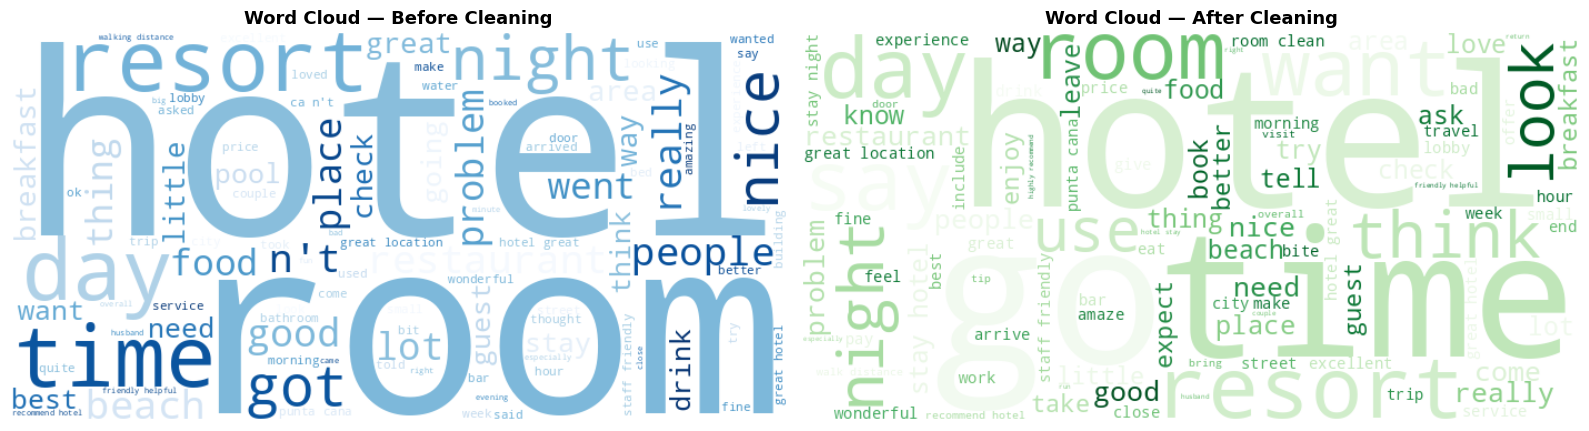

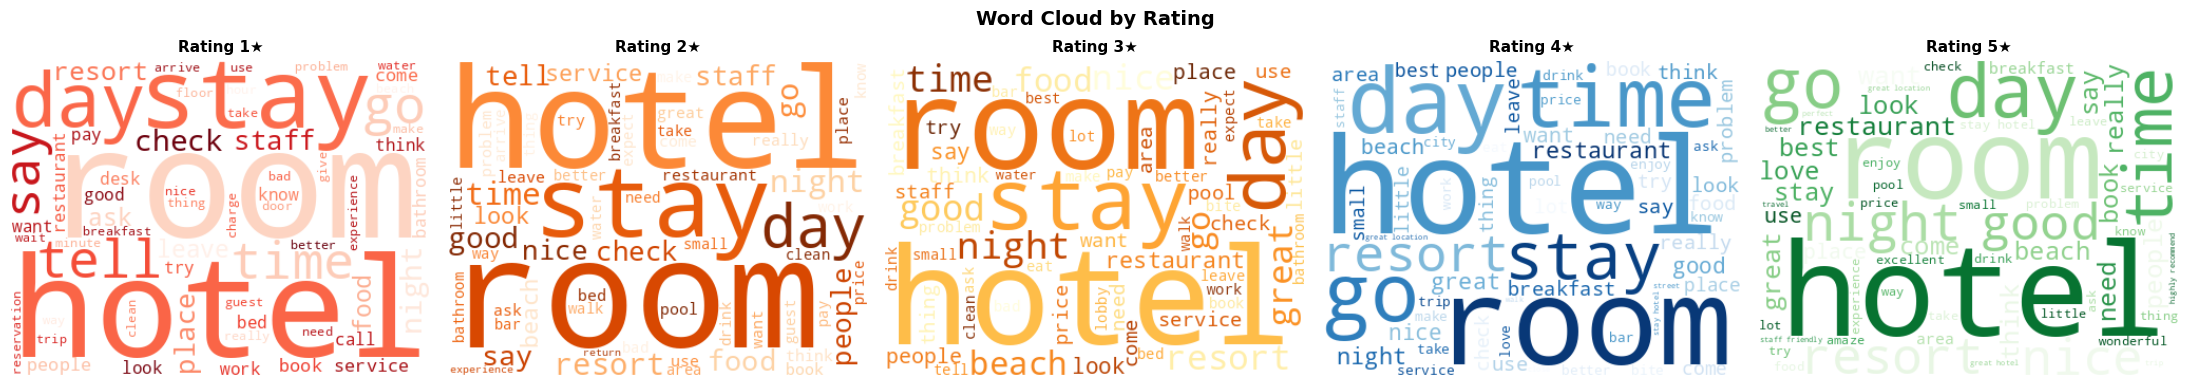

In [ ]:
# APPLY PREPROCESSING ───────────────────────────────────
print("Cleaning all reviews... (may take 1-2 minutes)")
start_clean = time.time()

df['cleaned_review'] = df['Review'].astype(str).apply(clean_text_pipeline)

clean_time = time.time() - start_clean
print(f"Done! Cleaning took {clean_time:.1f} seconds")

# Drop empty rows after cleaning
before = len(df)
df = df.dropna(subset=['cleaned_review'])
df = df[df['cleaned_review'].str.strip().str.len() > 5]
print(f"Removed {before - len(df)} empty rows after cleaning")
print(f"Remaining samples: {len(df)}")

# Word Cloud after cleaning
all_clean_text = " ".join(df['cleaned_review'].values)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before cleaning wordcloud
wc_raw = WordCloud(width=700, height=350, background_color='white',
                   colormap='Blues', max_words=100).generate(
    " ".join(df['Review'].astype(str).values))
axes[0].imshow(wc_raw, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud — Before Cleaning',
                  fontsize=13, fontweight='bold')

# After cleaning wordcloud
wc_clean = WordCloud(width=700, height=350, background_color='white',
                     colormap='Greens', max_words=100).generate(all_clean_text)
axes[1].imshow(wc_clean, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — After Cleaning',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds_comparison.png', dpi=150)
plt.show()

# Show rating-wise word clouds
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, rating in enumerate([1, 2, 3, 4, 5]):
    subset_text = " ".join(
        df[df['Rating'] == rating]['cleaned_review'].values)
    if len(subset_text) > 10:
        wc = WordCloud(width=400, height=300, background_color='white',
                       max_words=60,
                       colormap=['Reds','Oranges','YlOrBr',
                                 'Blues','Greens'][i]).generate(subset_text)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Rating {rating}★', fontsize=11, fontweight='bold')

plt.suptitle('Word Cloud by Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_by_rating.png', dpi=150)
plt.show()

  SPLIT SUMMARY
  Train : 14,343
  Val   : 3,074
  Test  : 3,074

  Cls       Train      Val     Test
  ---------------------------------
  1★         995      213      213
  2★       1,255      269      269
  3★       1,529      327      328
  4★       4,227      906      906
  5★       6,337    1,359    1,358

  Class Weights (smoothed):
  Cls         Raw   Smoothed
  ---------------------------
  1★       2.883      1.397
  2★       2.286      1.244
  3★       1.876      1.127
  4★       0.679      0.678
  5★       0.453      0.554


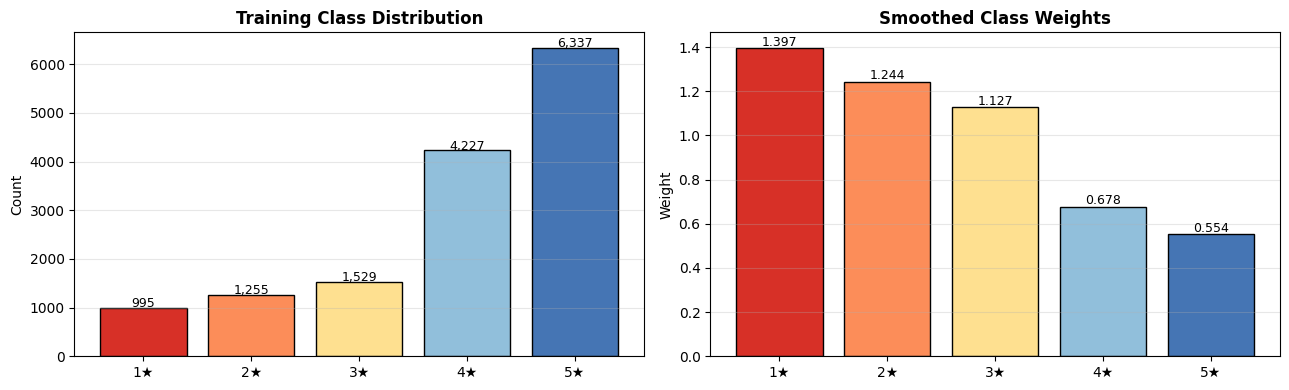

In [ ]:
# SPLIT & CLASS WEIGHTS ───────────────────────────────────

# FIX: Changed 'cleaned' to 'cleaned_review' to match the actual dataframe column name
X = df['cleaned_review'].values
y = (df['Rating'].values - 1).astype(int)   # 0..4

NUM_CLASSES = 5

# Stratified 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30,
    random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=42, stratify=y_temp)

print("=" * 50)
print("  SPLIT SUMMARY")
print("=" * 50)
print(f"  Train : {len(X_train):,}")
print(f"  Val   : {len(X_val):,}")
print(f"  Test  : {len(X_test):,}")
print(f"\n  {'Cls':<6} {'Train':>8} {'Val':>8} {'Test':>8}")
print(f"  {'-'*33}")
for c in range(NUM_CLASSES):
    print(f"  {c+1}★    "
          f"{np.sum(y_train==c):>8,} "
          f"{np.sum(y_val==c):>8,} "
          f"{np.sum(y_test==c):>8,}")

# ── CLASS WEIGHTS
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Smooth weights: sqrt dampens extreme values
smoothed = np.sqrt(raw_weights)

# Normalize so mean weight = 1.0
smoothed = smoothed / smoothed.mean()

class_weight_dict = dict(enumerate(smoothed))

print(f"\n  Class Weights (smoothed):")
print(f"  {'Cls':<6} {'Raw':>8} {'Smoothed':>10}")
print(f"  {'-'*27}")
for c, (raw, sm) in enumerate(
        zip(raw_weights, smoothed)):
    print(f"  {c+1}★    {raw:>8.3f} {sm:>10.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_p = ['#d73027','#fc8d59','#fee090',
            '#91bfdb','#4575b4']

counts = [np.sum(y_train==c) for c in range(NUM_CLASSES)]
axes[0].bar([f'{c+1}★' for c in range(NUM_CLASSES)],
            counts, color=colors_p, edgecolor='black')
axes[0].set_title('Training Class Distribution',
                  fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
for i, cnt in enumerate(counts):
    axes[0].text(i, cnt+20, f'{cnt:,}',
                 ha='center', fontsize=9)

axes[1].bar([f'{c+1}★' for c in range(NUM_CLASSES)],
            smoothed, color=colors_p, edgecolor='black')
axes[1].set_title('Smoothed Class Weights',
                  fontweight='bold')
axes[1].set_ylabel('Weight')
axes[1].grid(axis='y', alpha=0.3)
for i, w in enumerate(smoothed):
    axes[1].text(i, w+0.01, f'{w:.3f}',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_weights.png', dpi=150)
plt.show()

  TOKENIZATION SUMMARY
  Unique tokens    : 34,905
  Vocab cap        : 20,000
  90th pct length  : 188
  MAX_LEN (used)   : 120
  Batch size       : 256

  X_train_pad shape : (14343, 120)
  X_val_pad shape   : (3074, 120)


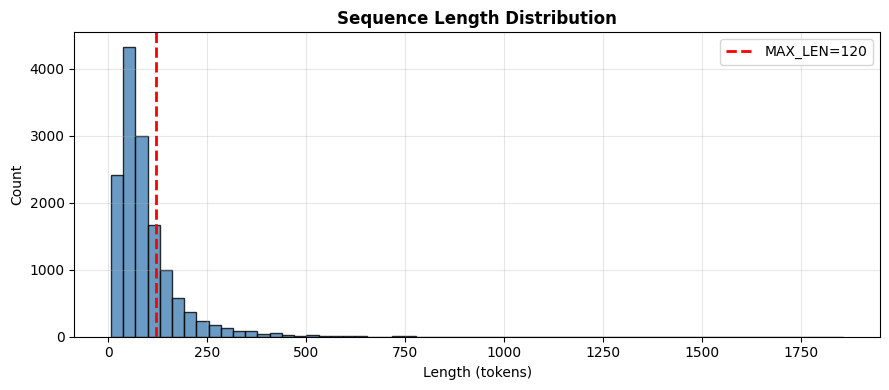

In [ ]:
# TOKENIZATION & PADDING ───────────────────────────────────


VOCAB_SIZE   = 20000
EMBED_DIM    = 128
BATCH_SIZE   = 256    # Large batch = stable gradients
MAX_EPOCHS   = 25
NUM_CLASSES  = 5

# Tokenize on train only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index

# Get sequence lengths
train_seqs  = tokenizer.texts_to_sequences(X_train)
seq_lengths = [len(s) for s in train_seqs]

# Use 90th percentile to reduce padding noise
p90     = int(np.percentile(seq_lengths, 90))
MAX_LEN = min(p90, 120)   # Hard cap at 120 for efficiency

print("=" * 55)
print("  TOKENIZATION SUMMARY")
print("=" * 55)
print(f"  Unique tokens    : {len(word_index):,}")
print(f"  Vocab cap        : {VOCAB_SIZE:,}")
print(f"  90th pct length  : {p90}")
print(f"  MAX_LEN (used)   : {MAX_LEN}")
print(f"  Batch size       : {BATCH_SIZE}")

# Pad all splits
def make_padded(seqs):
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_pad = make_padded(train_seqs)
X_val_pad   = make_padded(tokenizer.texts_to_sequences(X_val))
X_test_pad  = make_padded(tokenizer.texts_to_sequences(X_test))

print(f"\n  X_train_pad shape : {X_train_pad.shape}")
print(f"  X_val_pad shape   : {X_val_pad.shape}")

# Visualize sequence lengths
plt.figure(figsize=(9, 4))
plt.hist(seq_lengths, bins=60, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN}')
plt.title('Sequence Length Distribution', fontweight='bold')
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# HELPER: PLOT & EVALUATE ───────────────────────────────────

def plot_history(history, model_name,
                 c_tr='#1565C0', c_va='#C62828'):
    epochs = range(1, len(history.history['loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training History',
                 fontsize=13, fontweight='bold')

    # Loss
    axes[0].plot(epochs, history.history['loss'],
                 color=c_tr, lw=2, marker='o',
                 ms=3, label='Train Loss')
    axes[0].plot(epochs, history.history['val_loss'],
                 color=c_va, lw=2, marker='s',
                 ms=3, ls='--', label='Val Loss')
    best = int(np.argmin(history.history['val_loss']))
    axes[0].axvline(best+1, color='green', ls=':',
                    lw=2, label=f'Best Ep={best+1}')
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history.history['accuracy'],
                 color=c_tr, lw=2, marker='o',
                 ms=3, label='Train Acc')
    axes[1].plot(epochs, history.history['val_accuracy'],
                 color=c_va, lw=2, marker='s',
                 ms=3, ls='--', label='Val Acc')
    bv = max(history.history['val_accuracy'])
    axes[1].axhline(bv, color='green', ls=':',
                    lw=1.5, label=f'Best Val={bv:.3f}')
    axes[1].set_title('Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Overfit gap
    tr_last = history.history['accuracy'][-1]
    va_last = history.history['val_accuracy'][-1]
    gap     = tr_last - va_last
    col     = ('green'  if gap < 0.07 else
               'orange' if gap < 0.13 else 'red')
    axes[1].annotate(
        f'Gap={gap:.3f} '
        f'{"✓ OK" if gap<0.07 else "⚠ Overfit"}',
        xy=(0.97, 0.04), xycoords='axes fraction',
        ha='right', fontsize=9, color=col,
        bbox=dict(boxstyle='round,pad=0.3',
                  fc='white', ec=col, alpha=0.85)
    )

    plt.tight_layout()
    safe = re.sub(r'[^a-zA-Z0-9_]', '_', model_name)
    plt.savefig(f'{safe}_history.png', dpi=150)
    plt.show()

    print(f"  Best Val Acc  : {bv:.4f} ({bv*100:.2f}%)")
    print(f"  Best Val Loss : "
          f"{min(history.history['val_loss']):.4f}")
    print(f"  Best Epoch    : {best+1}")
    print(f"  Overfit Gap   : {gap:.4f} "
          f"({'OK' if gap<0.07 else 'HIGH'})")
    return bv


def evaluate_model(model, X_pad, y_true,
                   model_name):
    cls_names = [f'{i+1}★' for i in range(NUM_CLASSES)]

    print(f"\n{'='*60}")
    print(f"  EVALUATION: {model_name}")
    print(f"{'='*60}")

    proba  = model.predict(X_pad, verbose=0)
    y_pred = np.argmax(proba, axis=1)
    acc    = accuracy_score(y_true, y_pred)

    print(f"  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=cls_names,
                                 zero_division=0))

    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / \
              cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name}',
                 fontsize=13, fontweight='bold')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cls_names,
                yticklabels=cls_names,
                ax=axes[0], linewidths=0.4)
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title('Raw Counts')

    sns.heatmap(cm_norm, annot=True, fmt='.2f',
                cmap='YlOrRd',
                xticklabels=cls_names,
                yticklabels=cls_names,
                ax=axes[1], linewidths=0.4,
                vmin=0, vmax=1)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_title('Row-Normalized (Recall)')

    plt.tight_layout()
    safe = re.sub(r'[^a-zA-Z0-9_]', '_', model_name)
    plt.savefig(f'{safe}_cm.png', dpi=150)
    plt.show()

    return acc, y_pred, proba


def get_callbacks(name, patience_es=6, patience_lr=3):
    """
    Callbacks tuned for stable training:
    - ES patience=6: enough room to converge
    - LR factor=0.5: gentle halving
    - min_delta=0.002: ignore tiny fluctuations
    """
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience_es,
            restore_best_weights=True,
            min_delta=0.002,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience_lr,
            min_lr=5e-6,
            min_delta=0.002,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f'{re.sub(chr(32),"_",name)}'
                     f'_best.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
    ]


print("Helpers ready.")
print(f"  MAX_LEN    = {MAX_LEN}")
print(f"  BATCH_SIZE = {BATCH_SIZE}")
print(f"  MAX_EPOCHS = {MAX_EPOCHS}")
print(f"  VOCAB_SIZE = {VOCAB_SIZE}")

Helpers ready.
  MAX_LEN    = 120
  BATCH_SIZE = 256
  MAX_EPOCHS = 25
  VOCAB_SIZE = 20000


In [ ]:
# Modal 1 - Simple RNN ───────────────────────────────────

K.clear_session()
tf.random.set_seed(42)

model1 = Sequential([
    Input(shape=(MAX_LEN,), name='input'),
    Embedding(VOCAB_SIZE, EMBED_DIM, name='embed'),
    SpatialDropout1D(0.45, name='spatial_drop'),

    Bidirectional(
        GRU(64, return_sequences=True,
            dropout=0.2, recurrent_dropout=0,
            kernel_regularizer=l2(0.005)),
        name='bigru'
    ),
    GlobalMaxPooling1D(name='gmp'),

    BatchNormalization(name='bn'),
    Dropout(0.5, name='drop1'),

    Dense(32, activation='relu', kernel_regularizer=l2(0.005), name='dense1'),
    Dropout(0.4, name='drop2'),

    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='Model1_Regularized_BiGRU')

model1.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()


Model: "Model1_Regularized_BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embed (Embedding)               │ (None, 120, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_drop (SpatialDropout1D) │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru (Bidirectional)           │ (None, 120, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gmp (GlobalMaxPooling1D)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,639,301 (10.07 MB)

 Trainable params: 2,639,045 (10.07 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# TRAIN MODEL 1 ───────────────────────────────────

print("\nTraining Model 1: Bidirectional SimpleRNN")
print("=" * 55)
print(f"  batch_size = {BATCH_SIZE}  "
      f"(large batch prevents class-weight collapse)")
print(f"  MAX_LEN    = {MAX_LEN}")
print(f"  weights    = smoothed sqrt (not raw balanced)")
print("=" * 55)

t0 = time.time()
history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('Model1_BiRNN'),
    shuffle=True,
    verbose=1
)
model1_time = time.time() - t0
print(f"\n  Time: {model1_time:.0f}s "
      f"({model1_time/60:.1f} min)")


Training Model 1: Bidirectional SimpleRNN
  batch_size = 256  (large batch prevents class-weight collapse)
  MAX_LEN    = 120
  weights    = smoothed sqrt (not raw balanced)
Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.2087 - loss: 2.8463 - val_accuracy: 0.4421 - val_loss: 2.7950 - learning_rate: 5.0000e-04
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3064 - loss: 2.2793 - val_accuracy: 0.4421 - val_loss: 2.4070 - learning_rate: 5.0000e-04
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3928 - loss: 1.9254 - val_accuracy: 0.4421 - val_loss: 2.1353 - learning_rate: 5.0000e-04
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4483 - loss: 1.6760 - val_accuracy: 0.4421 - val_loss: 1.9245 - learning_rate: 5.0000e-04
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4889 - loss: 1.4963 - val_accuracy: 0.4512 - val_loss: 1.7585 - learning_rate: 5.0000e-04
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/ste

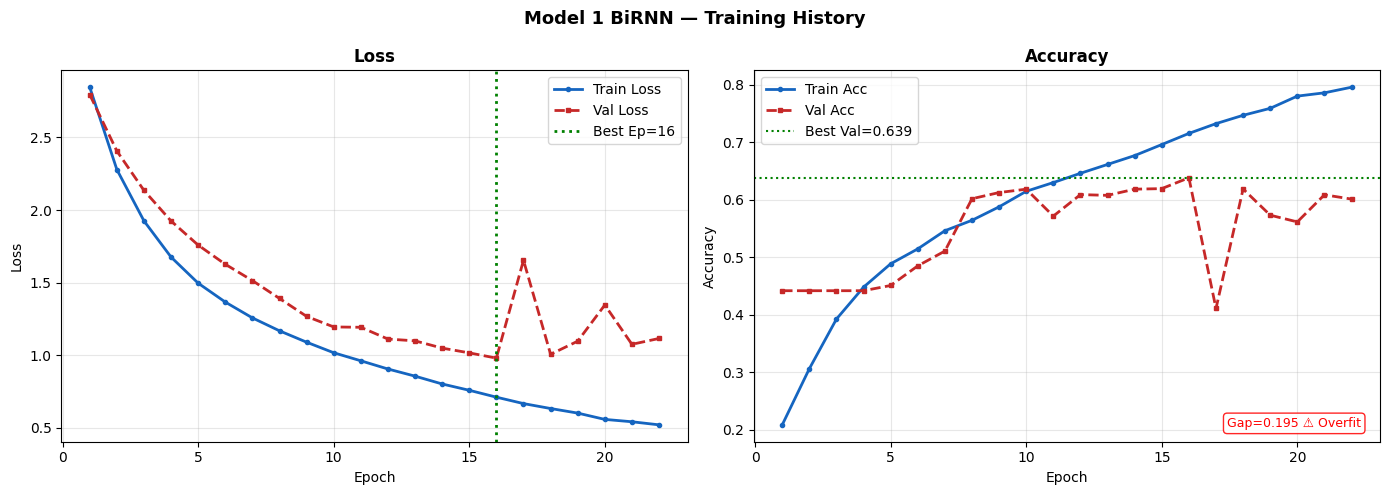

  Best Val Acc  : 0.6386 (63.86%)
  Best Val Loss : 0.9800
  Best Epoch    : 16
  Overfit Gap   : 0.1946 (HIGH)

  EVALUATION: Model1 BiRNN
  Test Accuracy : 0.6347 (63.47%)

  Classification Report:
              precision    recall  f1-score   support

          1★       0.70      0.66      0.68       213
          2★       0.50      0.45      0.48       269
          3★       0.41      0.40      0.41       328
          4★       0.56      0.50      0.53       906
          5★       0.74      0.82      0.77      1358

    accuracy                           0.63      3074
   macro avg       0.58      0.56      0.57      3074
weighted avg       0.63      0.63      0.63      3074



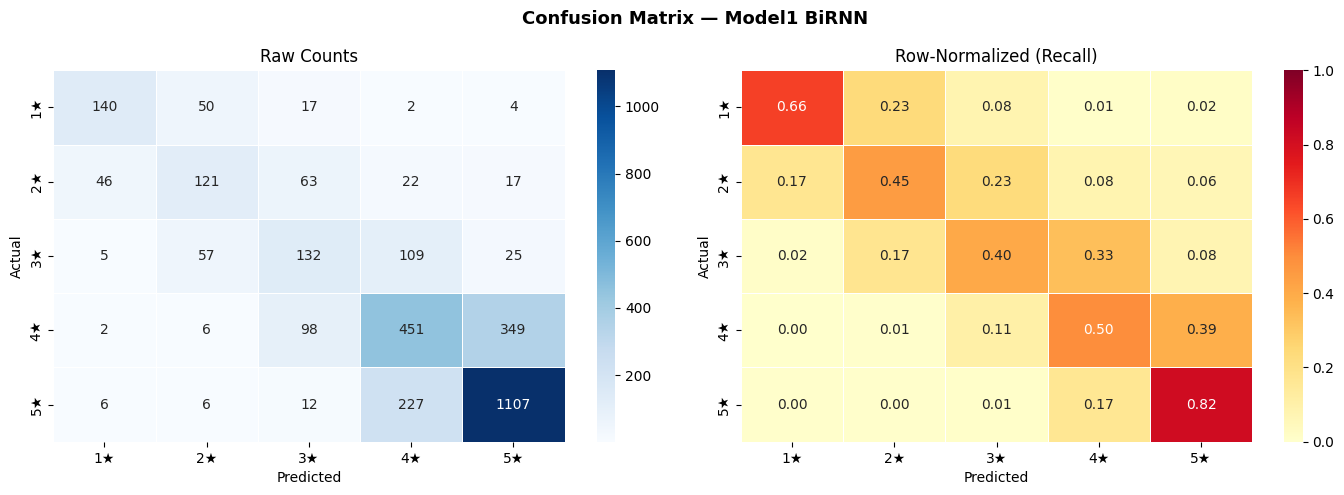

In [ ]:
# Evaluate Model 1 ─────────────────────────────────────────

bv1 = plot_history(history1, 'Model 1 BiRNN')
acc1, pred1, proba1 = evaluate_model(
    model1, X_test_pad, y_test, 'Model1 BiRNN')

In [ ]:
# Modal 2 ───────────────────────────────────

K.clear_session()
tf.random.set_seed(42)

# Model 2 Fix: Higher SpatialDropout and kernel constraints to force generalization
model2 = Sequential([
    Input(shape=(MAX_LEN,), name='input'),
    Embedding(VOCAB_SIZE, EMBED_DIM, name='embed'),
    SpatialDropout1D(0.5, name='spatial_drop'),

    Conv1D(64, kernel_size=3, padding='same', activation='relu', kernel_regularizer=l2(0.003)),
    Dropout(0.4, name='conv_drop'),

    Bidirectional(LSTM(32, return_sequences=True, kernel_regularizer=l2(0.003))),
    GlobalMaxPooling1D(),

    BatchNormalization(),
    Dropout(0.55),

    Dense(32, activation='relu', kernel_regularizer=l2(0.003)),
    Dropout(0.45),

    Dense(NUM_CLASSES, activation='softmax')
], name='Model2_Stable_ConvLSTM')

model2.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=0.5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model2.summary()

Model: "Model2_Stable_ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embed (Embedding)               │ (None, 120, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_drop (SpatialDropout1D) │ (None, 120, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 120, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_drop (Dropout)             │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 120, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,973 (9.96 MB)

 Trainable params: 2,611,845 (9.96 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# Train Model 2 ────────────────────────────

print("\nTraining Improved Model 2: Conv1D + BiLSTM + Global Pooling")
print("=" * 55)

t0 = time.time()
history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('Improved_Model2'),
    shuffle=True,
    verbose=1
)
model2_time = time.time() - t0
print(f"\n  Time: {model2_time:.0f}s ({model2_time/60:.1f} min)")


Training Improved Model 2: Conv1D + BiLSTM + Global Pooling
Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.2592 - loss: 2.0589 - val_accuracy: 0.4421 - val_loss: 2.2624 - learning_rate: 5.0000e-04
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.3474 - loss: 1.8386 - val_accuracy: 0.4421 - val_loss: 2.0733 - learning_rate: 5.0000e-04
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4019 - loss: 1.6629 - val_accuracy: 0.4421 - val_loss: 1.8851 - learning_rate: 5.0000e-04
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4553 - loss: 1.4670 - val_accuracy: 0.4421 - val_loss: 1.7048 - learning_rate: 5.0000e-04
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4911 - loss: 1.3237 - val_accuracy: 0.4512 - val_loss: 1.5647 - learning_rate: 5.0000e-04
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5315 - loss: 1.2069 - val_accuracy: 0.4915 - val_loss: 1.4616 - learning_rate: 5.0000e-04
Epoch 7/2

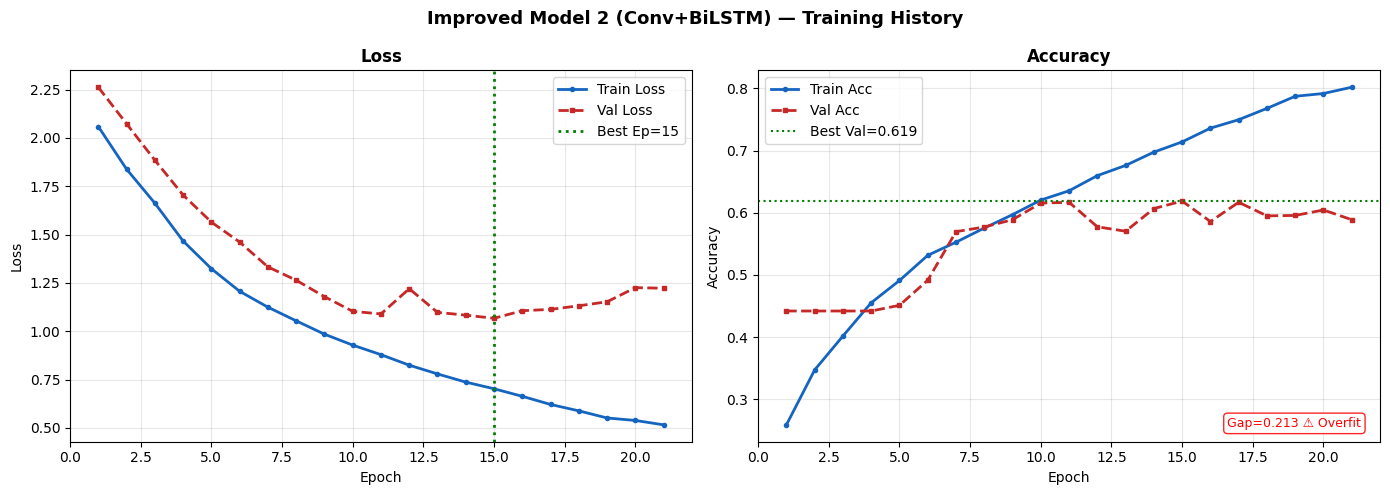

  Best Val Acc  : 0.6187 (61.87%)
  Best Val Loss : 1.0673
  Best Epoch    : 15
  Overfit Gap   : 0.2129 (HIGH)

  EVALUATION: Improved Model 2
  Test Accuracy : 0.6135 (61.35%)

  Classification Report:
              precision    recall  f1-score   support

          1★       0.74      0.60      0.66       213
          2★       0.46      0.33      0.38       269
          3★       0.38      0.33      0.36       328
          4★       0.51      0.51      0.51       906
          5★       0.73      0.81      0.77      1358

    accuracy                           0.61      3074
   macro avg       0.56      0.52      0.54      3074
weighted avg       0.60      0.61      0.61      3074



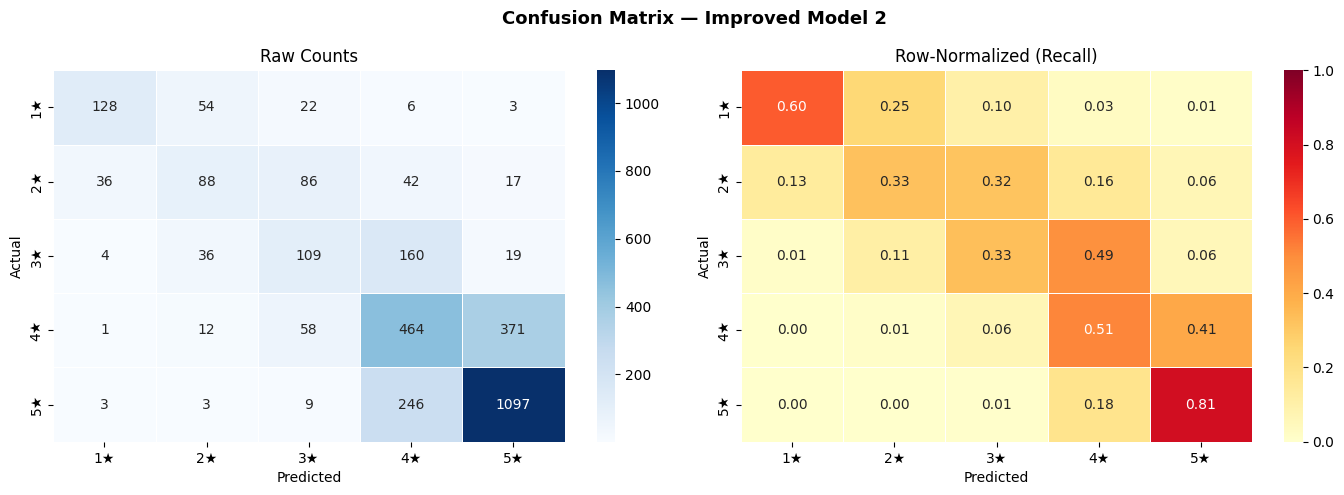


Improvement over Model 1: -2.11%


In [ ]:
# Evaluate Model 2 ────────────

bv2 = plot_history(history2, 'Improved Model 2 (Conv+BiLSTM)')
acc2, pred2, proba2 = evaluate_model(
    model2, X_test_pad, y_test, 'Improved Model 2')

print(f"\nImprovement over Model 1: {(acc2 - acc1)*100:+.2f}%")

In [ ]:
!pip install gensim
import gensim.downloader as api

try:
    _ = glove_model
    print("GloVe already in memory.")
except NameError:
    print("Downloading GloVe-100 (first run ~3 min)...")
    glove_model = api.load('glove-wiki-gigaword-100')
    print("Done!")

GLOVE_DIM = glove_model.vector_size
print(f"  GloVe vocab : {len(glove_model.key_to_index):,}")
print(f"  GloVe dim   : {GLOVE_DIM}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 85.5 MB/s eta 0:00:00
[==================================================] 100.0% 128.1/128.1MB downloaded
Done!
  GloVe vocab : 400,000
  GloVe dim   : 100


In [ ]:
# Build GloVe Embedding Matrix ─────────────────────────────

GLOVE_DIM = glove_model.vector_size   # 100

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found_count = 0
not_found = []

for word, idx in word_index.items():
    if idx < VOCAB_SIZE:
        if word in glove_model:
            embedding_matrix[idx] = glove_model[word]
            found_count += 1
        else:
            # Use small random values for OOV words
            embedding_matrix[idx] = np.random.normal(
                scale=0.1, size=(GLOVE_DIM,))
            not_found.append(word)

coverage = (found_count / min(len(word_index), VOCAB_SIZE)) * 100

print("=" * 50)
print("  GLOVE EMBEDDING MATRIX SUMMARY")
print("=" * 50)
print(f"  Words found in GloVe    : {found_count:,}")
print(f"  Words not found (OOV)   : {len(not_found):,}")
print(f"  GloVe coverage          : {coverage:.1f}%")
print(f"  Embedding matrix shape  : {embedding_matrix.shape}")
print(f"\n  Sample OOV words        : {not_found[:10]}")

  GLOVE EMBEDDING MATRIX SUMMARY
  Words found in GloVe    : 16,093
  Words not found (OOV)   : 3,906
  GloVe coverage          : 80.5%
  Embedding matrix shape  : (20000, 100)

  Sample OOV words        : ['<OOV>', 'housekeep', 'overprice', 'affinia', 'resturants', 'recomend', 'sunscape', 'reccomend', 'resturant', 'definetly']


In [ ]:
# Modal 3 ───────────────────────────────────

K.clear_session()
tf.random.set_seed(42)

model3 = Sequential([
    Input(shape=(MAX_LEN,), name='input'),
    Embedding(VOCAB_SIZE, GLOVE_DIM,
              weights=[embedding_matrix],
              trainable=False,
              name='glove_embed'),
    SpatialDropout1D(0.4),

    Conv1D(64, kernel_size=3, padding='same', activation='relu', kernel_regularizer=l2(0.002)),
    Bidirectional(LSTM(48, return_sequences=False, kernel_regularizer=l2(0.002))),

    BatchNormalization(),
    Dropout(0.5),

    Dense(32, activation='relu', kernel_regularizer=l2(0.002)),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
], name='Model3_GloVe_Frozen')

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model3.summary()

Model: "Model3_GloVe_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embed (Embedding)         │ (None, 120, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 120, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 120, 64)        │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 96)             │        43,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,066,309 (7.88 MB)

 Trainable params: 66,117 (258.27 KB)

 Non-trainable params: 2,000,192 (7.63 MB)

In [ ]:
# Train Model 3 ────────────────────────────────────────────

print("\nTraining Model 3: BiLSTM + GloVe")
print("=" * 55)

t0 = time.time()
history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('Model3_GloVe'),
    shuffle=True,
    verbose=1
)
model3_time = time.time() - t0
print(f"\n  Time: {model3_time:.0f}s "
      f"({model3_time/60:.1f} min)")


Training Model 3: BiLSTM + GloVe
Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.2756 - loss: 2.1645 - val_accuracy: 0.4629 - val_loss: 2.0046 - learning_rate: 0.0010
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.3703 - loss: 1.7495 - val_accuracy: 0.4180 - val_loss: 1.9167 - learning_rate: 0.0010
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.4087 - loss: 1.5716 - val_accuracy: 0.4811 - val_loss: 1.7571 - learning_rate: 0.0010
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.4328 - loss: 1.4547 - val_accuracy: 0.4990 - val_loss: 1.6643 - learning_rate: 0.0010
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.4588 - loss: 1.3616 - val_accuracy: 0.4802 - val_loss: 1.6486 - learning_rate: 0.0010
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.4851 - loss: 1.2798 - val_accuracy: 0.5010 - val_loss: 1.5173 - learning_rate: 0.0010
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accurac

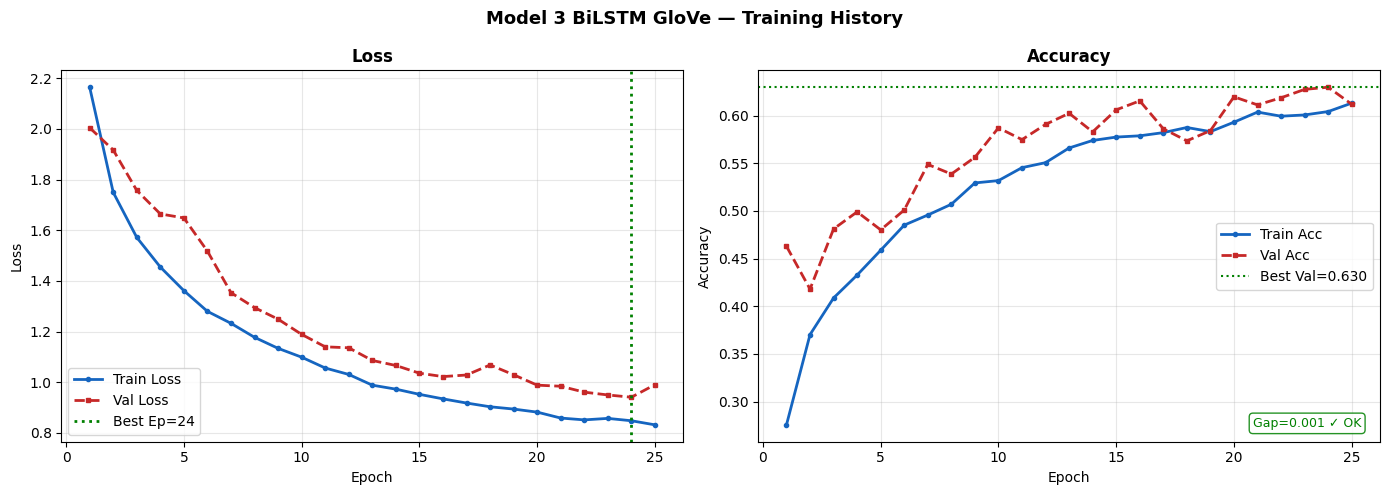

  Best Val Acc  : 0.6298 (62.98%)
  Best Val Loss : 0.9409
  Best Epoch    : 24
  Overfit Gap   : 0.0012 (OK)

  EVALUATION: Model3 BiLSTM GloVe
  Test Accuracy : 0.6236 (62.36%)

  Classification Report:
              precision    recall  f1-score   support

          1★       0.69      0.68      0.69       213
          2★       0.42      0.47      0.45       269
          3★       0.41      0.34      0.37       328
          4★       0.54      0.52      0.53       906
          5★       0.75      0.78      0.77      1358

    accuracy                           0.62      3074
   macro avg       0.56      0.56      0.56      3074
weighted avg       0.62      0.62      0.62      3074



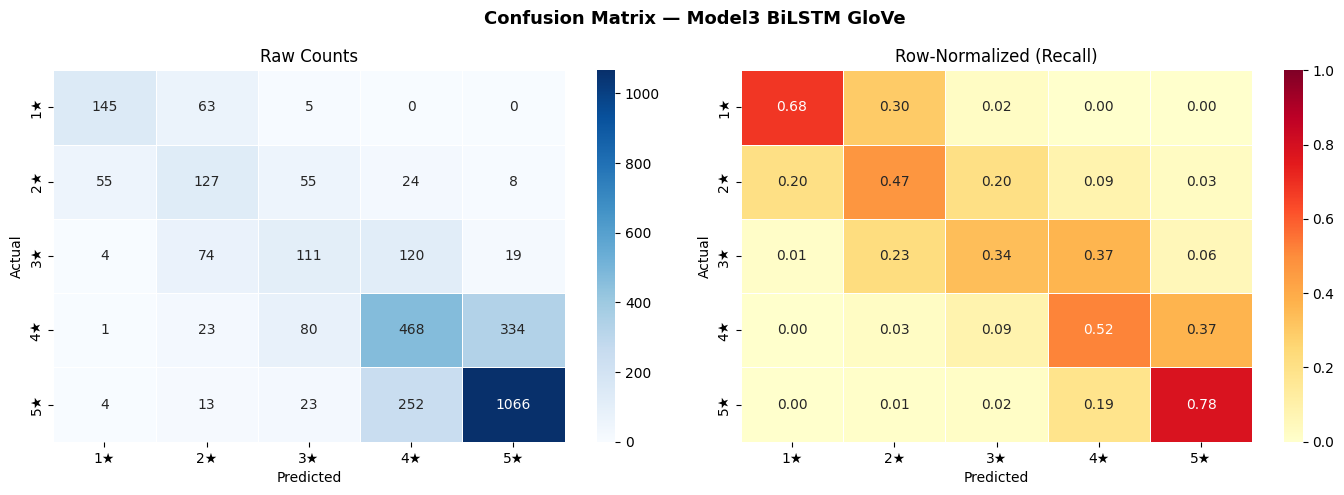

In [ ]:
# Evaluate Model 3 ─────────────────────────────────────────

bv3 = plot_history(history3, 'Model 3 BiLSTM GloVe')
acc3, pred3, proba3 = evaluate_model(
    model3, X_test_pad, y_test, 'Model3 BiLSTM GloVe')

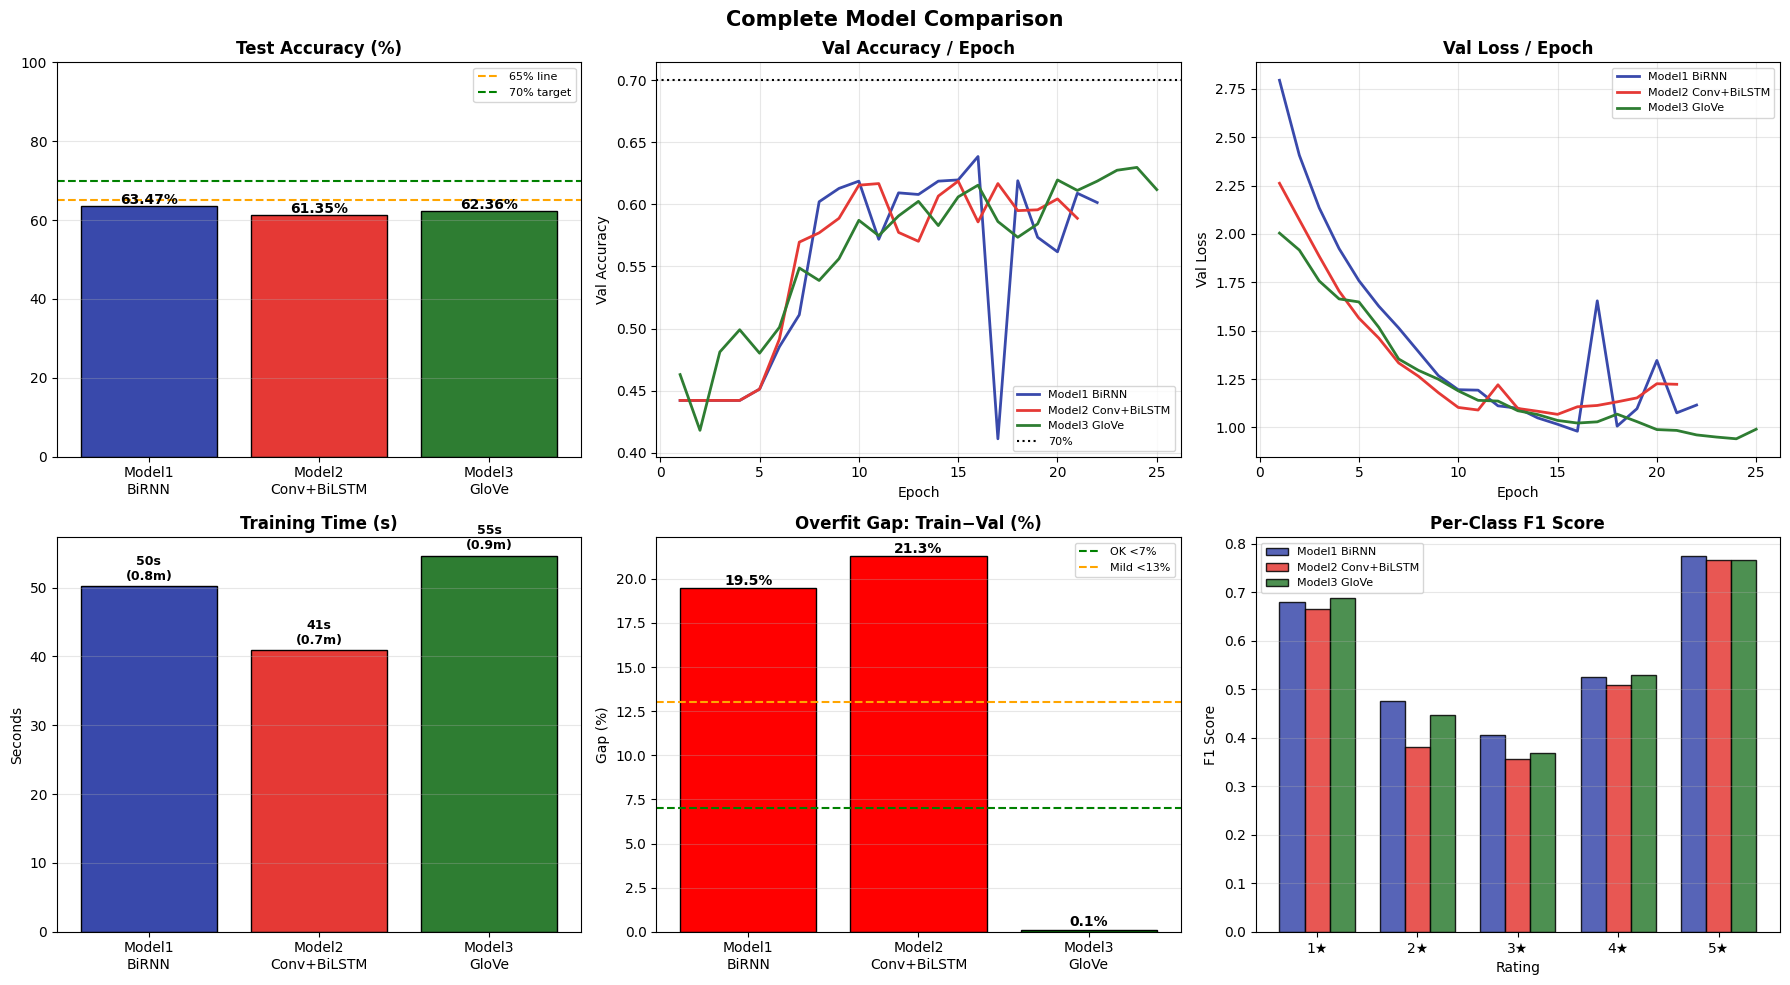


                           FINAL RESULTS                          
  Model                    Test%  BestVal%    Time     Params
  ----------------------------------------------------------
  Model1 (BiRNN)          63.47%    63.86%     50s  2,639,301
  Model2 (Conv+BiLSTM)    61.35%    61.87%     41s  2,611,973
  Model3 (GloVe)          62.36%    62.98%     55s  2,066,309

  Best : Model1 (BiRNN)
  Acc  : 63.47%


In [ ]:
# COMPREHENSIVE MODEL COMPARISON ───────────────────────

from sklearn.metrics import f1_score

labels    = ['Model1\nBiRNN',
             'Model2\nConv+BiLSTM',
             'Model3\nGloVe']
accs      = [acc1,        acc2,        acc3]
bvals     = [bv1,         bv2,         bv3]
times     = [model1_time, model2_time, model3_time]
params    = [model1.count_params(),
             model2.count_params(),
             model3.count_params()]
clr_m     = ['#3949AB','#E53935','#2E7D32']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Complete Model Comparison',
             fontsize=15, fontweight='bold')

# 1. Test Accuracy
b1 = axes[0,0].bar(labels, [a*100 for a in accs],
                    color=clr_m, edgecolor='black')
axes[0,0].axhline(65, color='orange', ls='--',
                   lw=1.5, label='65% line')
axes[0,0].axhline(70, color='green', ls='--',
                   lw=1.5, label='70% target')
axes[0,0].set_title('Test Accuracy (%)',
                     fontweight='bold')
axes[0,0].set_ylim(0, 100)
axes[0,0].legend(fontsize=8)
axes[0,0].grid(axis='y', alpha=0.3)
for bar, a in zip(b1, accs):
    axes[0,0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f'{a*100:.2f}%', ha='center',
        fontweight='bold', fontsize=10)

# 2. Val Accuracy curves
for hist, lbl, c in zip(
        [history1,history2,history3], labels, clr_m):
    ep = range(1, len(hist.history['val_accuracy'])+1)
    axes[0,1].plot(ep, hist.history['val_accuracy'],
                   color=c, lw=2,
                   label=lbl.replace('\n',' '))
axes[0,1].axhline(0.70, color='black', ls=':',
                   lw=1.5, label='70%')
axes[0,1].set_title('Val Accuracy / Epoch',
                     fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Val Accuracy')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(alpha=0.3)

# 3. Val Loss curves
for hist, lbl, c in zip(
        [history1,history2,history3], labels, clr_m):
    ep = range(1, len(hist.history['val_loss'])+1)
    axes[0,2].plot(ep, hist.history['val_loss'],
                   color=c, lw=2,
                   label=lbl.replace('\n',' '))
axes[0,2].set_title('Val Loss / Epoch',
                     fontweight='bold')
axes[0,2].set_xlabel('Epoch')
axes[0,2].set_ylabel('Val Loss')
axes[0,2].legend(fontsize=8)
axes[0,2].grid(alpha=0.3)

# 4. Training Time
b4 = axes[1,0].bar(labels, times, color=clr_m,
                    edgecolor='black')
axes[1,0].set_title('Training Time (s)',
                     fontweight='bold')
axes[1,0].set_ylabel('Seconds')
axes[1,0].grid(axis='y', alpha=0.3)
for bar, t in zip(b4, times):
    axes[1,0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        f'{t:.0f}s\n({t/60:.1f}m)',
        ha='center', fontweight='bold', fontsize=9)

# 5. Overfit Gap
gaps = []
for h in [history1, history2, history3]:
    tr = h.history['accuracy'][-1]
    va = h.history['val_accuracy'][-1]
    gaps.append(tr - va)
gc = ['green' if g<0.07 else
      'orange' if g<0.13 else 'red'
      for g in gaps]
b5 = axes[1,1].bar(labels, [g*100 for g in gaps],
                    color=gc, edgecolor='black')
axes[1,1].axhline(7,  color='green',  ls='--',
                   lw=1.5, label='OK <7%')
axes[1,1].axhline(13, color='orange', ls='--',
                   lw=1.5, label='Mild <13%')
axes[1,1].set_title('Overfit Gap: Train−Val (%)',
                     fontweight='bold')
axes[1,1].set_ylabel('Gap (%)')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(axis='y', alpha=0.3)
for bar, g in zip(b5, gaps):
    axes[1,1].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.2,
        f'{g*100:.1f}%', ha='center',
        fontweight='bold', fontsize=10)

# 6. Per-class F1
f1s = [
    f1_score(y_test, p, average=None, zero_division=0)
    for p in [pred1, pred2, pred3]
]
x   = np.arange(NUM_CLASSES)
w   = 0.25
for i, (f, lbl, c) in enumerate(
        zip(f1s, labels, clr_m)):
    axes[1,2].bar(x + (i-1)*w, f, w,
                  label=lbl.replace('\n',' '),
                  color=c, alpha=0.85,
                  edgecolor='black')
axes[1,2].set_title('Per-Class F1 Score',
                     fontweight='bold')
axes[1,2].set_xlabel('Rating')
axes[1,2].set_ylabel('F1 Score')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(
    ['1★','2★','3★','4★','5★'])
axes[1,2].legend(fontsize=8)
axes[1,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "=" * 68)
print(f"  {'FINAL RESULTS':^64}")
print("=" * 68)
print(f"  {'Model':<22} {'Test%':>7} "
      f"{'BestVal%':>9} {'Time':>7} {'Params':>10}")
print(f"  {'-'*58}")
rows = ['Model1 (BiRNN)',
        'Model2 (Conv+BiLSTM)',
        'Model3 (GloVe)']
for nm, a, bv, t, p in zip(
        rows, accs, bvals, times, params):
    print(f"  {nm:<22} {a*100:>6.2f}% "
          f"{bv*100:>8.2f}% {t:>6.0f}s {p:>10,}")
print("=" * 68)

best_idx  = int(np.argmax(accs))
best_name = rows[best_idx]
print(f"\n  Best : {best_name}")
print(f"  Acc  : {accs[best_idx]*100:.2f}%")

In [ ]:
# ERROR ANALYSIS ───────────────────────────────────────

all_preds = [pred1, pred2, pred3]
all_names = ['BiRNN','Conv+BiLSTM','GloVe']
best_pred = all_preds[best_idx]
wrong_idx = np.where(best_pred != y_test)[0]

print("=" * 60)
print("  ERROR ANALYSIS")
print("=" * 60)
print(f"\n  Model    Wrong   Total   Accuracy")
print(f"  {'-'*40}")
for p, n in zip(all_preds, all_names):
    w = np.sum(p != y_test)
    t = len(y_test)
    print(f"  {n:<12} {w:>5}  {t:>7}  "
          f"{(1-w/t)*100:.2f}%")

print(f"\n  Per-Class Error Rate ({best_name}):")
print(f"  {'Cls':<6} {'Correct':>8} "
      f"{'Wrong':>7} {'Total':>7} {'Err%':>7}")
print(f"  {'-'*40}")
for c in range(NUM_CLASSES):
    tot  = np.sum(y_test == c)
    wrng = np.sum((y_test==c) & (best_pred!=c))
    corr = tot - wrng
    pct  = wrng/tot*100 if tot else 0
    print(f"  {c+1}★    {corr:>8} "
          f"{wrng:>7} {tot:>7} {pct:>6.1f}%")

print(f"\n  Sample Misclassified Examples:")
print(f"  {'-'*55}")
for tc in [0, 1, 2]:
    wrong_c = [i for i in wrong_idx
               if y_test[i] == tc]
    print(f"\n  True={tc+1}★  (total wrong={len(wrong_c)})")
    for j, idx in enumerate(wrong_c[:2]):
        preview = X_test[idx][:75]
        print(f"  [{j+1}] '{preview}...'")
        print(f"       True={y_test[idx]+1}★  "
              f"Pred={best_pred[idx]+1}★")

print(f"\n  Error Causes:")
print(f"  1. 3★ reviews are inherently ambiguous")
print(f"  2. Class imbalance despite smoothed weights")
print(f"  3. Short cleaned reviews lose context")
print(f"  4. Sarcasm not captured by word-level models")
print(f"\n  Improvements:")
print(f"  1. BERT/RoBERTa for context-aware encoding")
print(f"  2. Focal loss for hard-example focus")
print(f"  3. Minority class augmentation")
print(f"  4. Ensemble of all 3 models")

  ERROR ANALYSIS

  Model    Wrong   Total   Accuracy
  ----------------------------------------
  BiRNN         1123     3074  63.47%
  Conv+BiLSTM   1188     3074  61.35%
  GloVe         1157     3074  62.36%

  Per-Class Error Rate (Model1 (BiRNN)):
  Cls     Correct   Wrong   Total    Err%
  ----------------------------------------
  1★         140      73     213   34.3%
  2★         121     148     269   55.0%
  3★         132     196     328   59.8%
  4★         451     455     906   50.2%
  5★        1107     251    1358   18.5%

  Sample Misclassified Examples:
  -------------------------------------------------------

  True=1★  (total wrong=73)
  [1] 'miss stay hotel friend weekend september stay recommend friend book basis s...'
       True=1★  Pred=2★
  [2] 'definitely not star hotel puzzle hotel get star rat room supposedly differe...'
       True=1★  Pred=3★

  True=2★  (total wrong=148)
  [1] 'okay husband stay hotel weeks jan claim star truly feel like read review go..

In [ ]:
# Real-time Prediction gradio GUI ───────────────────────────────────

import subprocess, sys

try:
    import gradio as gr
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gradio'])
    import gradio as gr

# Use the best model found during comparison
best_models = [model1, model2, model3]
best_model  = best_models[best_idx]
best_acc    = accs[best_idx]

print(f"  GUI model : {best_name}")
print(f"  Test Acc  : {best_acc*100:.2f}%")

def predict_rating(review_text):
    if not review_text or not review_text.strip():
        return "Please enter a hotel review."

    # FIX: Corrected function name from clean_text to clean_text_pipeline
    cleaned = clean_text_pipeline(review_text)
    if len(cleaned.strip()) < 3:
        return "Review too short after cleaning."

    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN,
                            padding='post',
                            truncating='post')

    proba    = best_model.predict(padded, verbose=0)[0]
    pred_cls = int(np.argmax(proba)) + 1
    conf     = float(np.max(proba)) * 100
    stars    = '⭐' * pred_cls
    sent     = ('😊 Positive' if pred_cls >= 4 else
                '😐 Neutral'  if pred_cls == 3 else
                '😞 Negative')

    prob_str = '\n'.join([
        f"  {'⭐'*(i+1)} {i+1}★ : {p*100:5.1f}%"
        for i, p in enumerate(proba)
    ])

    return (
        f"{'─'*44}\n"
        f"  Predicted : {stars} ({pred_cls}/5)\n"
        f"  Sentiment : {sent}\n"
        f"  Confidence: {conf:.1f}%\n"
        f"{'─'*44}\n"
        f"  Probabilities:\n{prob_str}\n"
        f"{'─'*44}\n"
        f"  Model     : {best_name}\n"
        f"  Accuracy  : {best_acc*100:.2f}%\n"
        f"  Cleaned   : {cleaned[:60]}..."
    )

demo = gr.Interface(
    fn=predict_rating,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter hotel review here...",
        label="Hotel Review"
    ),
    outputs=gr.Textbox(label="Result", lines=16),
    title="Hotel Review Rating Predictor",
    description=(
        f"**{best_name}** | "
        f"Test Accuracy: **{best_acc*100:.2f}%**"
    ),
    examples=[
        ["Absolutely fantastic hotel! Spotless rooms, "
         "amazing staff, perfect breakfast. "
         "Will return!"],
        ["Terrible stay. Dirty room, AC broken, "
         "staff rude. Total waste of money."],
        ["Decent hotel for the price. "
         "Location good, nothing special."],
        ["Rooms smaller than photos suggested. "
         "Staff friendly but service slow."],
        ["Best hotel ever! Every detail was perfect. "
         "Highly recommend to everyone!"]
    ],
    theme=gr.themes.Soft(),
    allow_flagging='never'
)

demo.launch(share=True, inline=True, quiet=False)

  GUI model : Model1 (BiRNN)
  Test Acc  : 63.47%
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6d183776baa0cbdd07.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
